# Kayla Hammonds

This file computes computes our accuracy scores by using embeddings and cosine similarity.

First, we create a master .csv file of Wikipedia chunks by combining all wiki_texts.csv files. Then, using this newly created dataset ('wiki_df') and the preprocessed climate_df, we used SentenceTransformers to embed both dataset texts, conduct cosine similarity to find the most semantically similar matches, and then added these matches back to the wiki_df. The end of the file consists of early-stage visualizations/analysis.

AI was used to create the master .csv file of Wikipedia chunks.

In [33]:
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk import sent_tokenize
from nltk import word_tokenize
import numpy as np
import pandas as pd
import csv
from sentence_transformers import SentenceTransformer, util
import glob
import os
import matplotlib.pyplot as plt


In [ ]:
# this code creates a dataset of all wiki_texts .csv files 

# folder containing csv files
folder_path = "/Users/kayla/macs30112/wiki_texts" # change path to replicate

# get all csv files
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# read and combine
df_list = [pd.read_csv(file) for file in csv_files]
merged_df = pd.concat(df_list, ignore_index=True)

# save merged file
merged_df.to_csv("/Users/kayla/macs30112/merged_file.csv", index=False) # change path to replicate

In [ ]:
# load climate df and wiki df
climate_df = pd.read_csv('climate_df.csv')
wiki_df = pd.read_csv('merged_file.csv')

In [ ]:
# embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

reddit_embeddings = model.encode(climate_df['Post text'].tolist(), batch_size=64, show_progress_bar=True)
wiki_embeddings = model.encode(wiki_df['chunk_text'].tolist(), batch_size=64, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1312 [00:00<?, ?it/s]

Batches:   0%|          | 0/145 [00:00<?, ?it/s]

In [ ]:
# compute the cosine similarity scores
scores = cosine_similarity(reddit_embeddings, wiki_embeddings)

In [16]:
scores.shape
# num_reddit_comments, num_wiki_chunks

(83938, 9218)

In [17]:
# find best matches
best_match_idx = np.argmax(scores, axis=1)
best_scores = np.max(scores, axis=1)

In [ ]:
# attach best matches to climate_df with scores
climate_df['best_wiki_chunk'] = wiki_df.iloc[best_match_idx]['chunk_text'].values
climate_df['similarity_score'] = best_scores

In [19]:
climate_df.head(10)

,Date,Post text,Post type,# upvotes,# comments,# awards,Post tone,Post URL,Community name,Community members,Years of membership,engagement_rate,topic,engagement_log,best_wiki_chunk,similarity_score
0,2022-01-19,"Scientists urge quick, deep, sweeping changes ...",link,12672.0,839.0,0.0,neutral,https://reddit.com/r/EverythingScience/comment...,r/EverythingScience,481755.0,15.046575,2.804538,Biodiversity_Loss,1.336194,These changes of land and ocean ecosystems hav...,0.661592
1,2020-09-28,â€˜Extinction is foreverâ€™: World leaders ple...,link,7111.0,188.0,0.0,neutral,https://reddit.com/r/worldnews/comments/j1dfwb...,r/worldnews,33074462.0,7.747945,0.022068,Biodiversity_Loss,0.021828,Climate change is a major driver of biodiversi...,0.519659
2,2018-11-06,Stop biodiversity loss or we could face our ow...,link,3287.0,249.0,0.0,neutral,https://reddit.com/r/worldnews/comments/9uqc92...,r/worldnews,33074462.0,7.684932,0.010691,Biodiversity_Loss,0.010634,These changes of land and ocean ecosystems hav...,0.639425
3,2019-02-23,World's food supply 'under threat' from increa...,link,6653.0,650.0,0.0,neutral,https://reddit.com/r/worldnews/comments/atvjiw...,r/worldnews,33074462.0,10.394521,0.022080,Biodiversity_Loss,0.021840,Climate change can threaten food security and ...,0.641734
4,2023-06-03,[OC] 'Stripes' chart showing biodiversity loss...,link,418.0,67.0,0.0,neutral,https://reddit.com/r/dataisbeautiful/comments/...,r/dataisbeautiful,20019378.0,5.986301,0.002423,Biodiversity_Loss,0.002420,Climate change has been linked with the increa...,0.505905
5,2023-07-20,Biodiversity loss worryingly high,link,159.0,33.0,0.0,neutral,https://reddit.com/r/collapse/comments/154c8fd...,r/collapse,490494.0,0.947945,0.039144,Biodiversity_Loss,0.038397,These changes of land and ocean ecosystems hav...,0.705539
6,2022-07-11,Overpopulation is a major cause of biodiversit...,link,1093.0,270.0,0.0,neutral,https://reddit.com/r/collapse/comments/vwovof/...,r/collapse,490494.0,1.290411,0.277883,Biodiversity_Loss,0.245205,These changes of land and ocean ecosystems hav...,0.673389
7,2022-02-14,"Scientists urge quick, deep, sweeping changes ...",link,762.0,121.0,0.0,neutral,https://reddit.com/r/collapse/comments/ssoujo/...,r/collapse,490494.0,6.383562,0.180023,Biodiversity_Loss,0.165534,These changes of land and ocean ecosystems hav...,0.661592
8,2022-11-10,Deforestation and grassland conversion are the...,link,1498.0,30.0,0.0,neutral,https://reddit.com/r/science/comments/yrsqpv/d...,r/science,30784582.0,2.093151,0.004964,Biodiversity_Loss,0.004951,Climate change is a major driver of biodiversi...,0.689795
9,2021-02-19,Humans are making Earth a broken and increasin...,link,25227.0,1802.0,0.0,neutral,https://reddit.com/r/worldnews/comments/lnkptr...,r/worldnews,33074462.0,3.046575,0.081722,Biodiversity_Loss,0.078554,Climate change has an increasingly large impac...,0.601814


In [32]:
# descriptive analysis of scores
climate_df['similarity_score'].describe()

count    83938.000000
mean         0.481671
std          0.161079
min          0.071509
25%          0.348519
50%          0.506853
75%          0.612014
max          0.892771
Name: similarity_score, dtype: float64

In [ ]:
climate_df[climate_df['similarity_score'] < 0.08] # checking the lowest score (0.071509)

,Date,Post text,Post type,# upvotes,# comments,# awards,Post tone,Post URL,Community name,Community members,Years of membership,engagement_rate,topic,engagement_log,best_wiki_chunk,similarity_score
75767,2022-10-16,Danny Trejo and His 3rd Wife Joanne in 1976,link,4054.0,215.0,0.0,neutral,https://reddit.com/r/OldSchoolCool/comments/y5...,r/OldSchoolCool,18206630.0,2.876712,0.023448,wildfires,0.023177,Since the possessive agreement suffixes on nou...,0.071509


In [ ]:
climate_df.loc[75767]['Post URL'] # lowest score url 

'https://reddit.com/r/OldSchoolCool/comments/y5tkvg/danny_trejo_and_his_3rd_wife_joanne_in_1976/'

In [ ]:
climate_df[climate_df['similarity_score'] > 0.89] # checking the highest score (0.892771)

,Date,Post text,Post type,# upvotes,# comments,# awards,Post tone,Post URL,Community name,Community members,Years of membership,engagement_rate,topic,engagement_log,best_wiki_chunk,similarity_score
45183,2022-03-14,The Intergovernmental Panel on Climate change ...,text,1.0,0.0,0.0,neutral,https://reddit.com/r/niftywriters/comments/teb...,r/niftywriters,24.0,2.263014,4.166667,Intergovernmental_Panel_on_Climate_Change,1.642228,The Intergovernmental Panel on Climate Change ...,0.892771


In [ ]:
climate_df.loc[45183]['Post URL'] # highest score url

'https://reddit.com/r/niftywriters/comments/tebdzs/the_intergovernmental_panel_on_climate_change/'

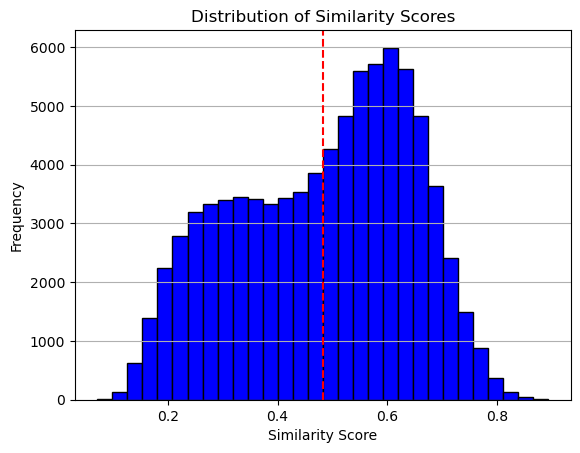

In [ ]:
# see distribution of scores


plt.hist(climate_df['similarity_score'], bins=30, color='blue', edgecolor='black')
plt.title('Distribution of Similarity Scores')
plt.xlabel('Similarity Score')
plt.axvline(climate_df['similarity_score'].mean(), linestyle="--", color="red") 
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

In [ ]:
climate_df['similarity_score'].mean() # average score

np.float32(0.4816711)

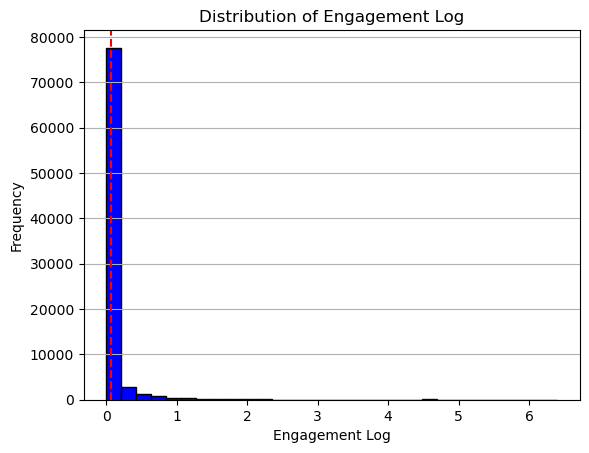

In [54]:
plt.hist(climate_df['engagement_log'], bins=30, color='blue', edgecolor='black')
plt.title('Distribution of Engagement Log')
plt.xlabel('Engagement Log')
plt.axvline(climate_df['engagement_log'].mean(), linestyle="--", color="red") 
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

In [64]:
climate_df['engagement_log'].mean() # average engagement log

np.float64(0.06762734345926204)

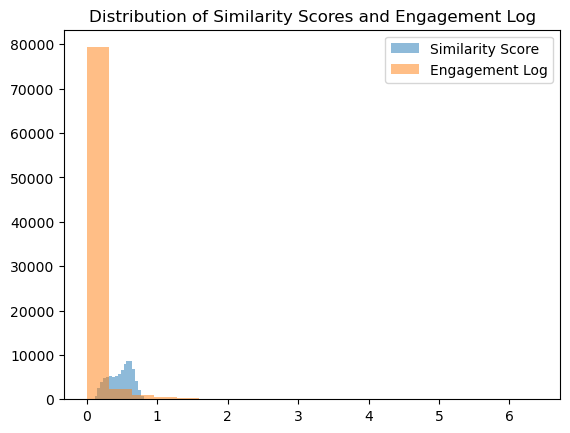

In [41]:
plt.hist(climate_df['similarity_score'], alpha=0.5, label='Similarity Score', bins=20)
plt.hist(climate_df['engagement_log'], alpha=0.5, label='Engagement Log', bins=20)
plt.legend()
plt.title('Distribution of Similarity Scores and Engagement Log')
plt.show()

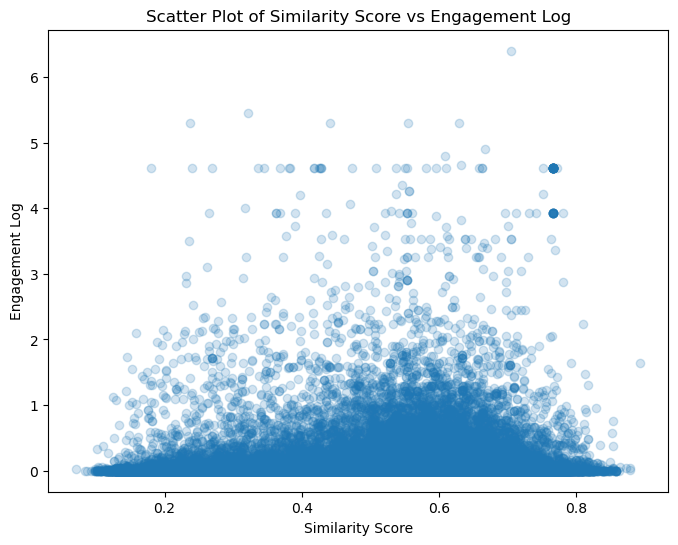

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(climate_df['similarity_score'], climate_df['engagement_log'], alpha=0.2)
plt.xlabel('Similarity Score')
plt.ylabel('Engagement Log')
plt.title('Scatter Plot of Similarity Score vs Engagement Log')
plt.show()

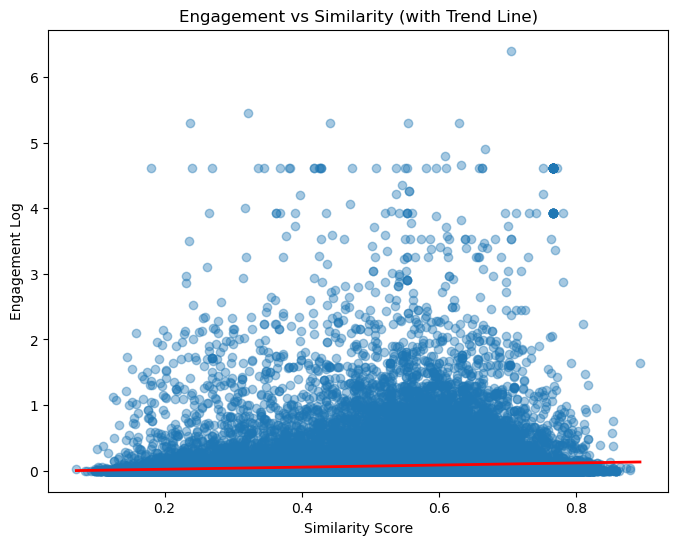

In [ ]:
# regression visualization


x = climate_df['similarity_score']
y = climate_df['engagement_log']

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.4)

# compute best-fit line
m, b = np.polyfit(x, y, 1)
x_sorted = np.sort(x)
plt.plot(x_sorted, m * x_sorted + b, color='red', linewidth=2)

plt.xlabel("Similarity Score")
plt.ylabel("Engagement Log")
plt.title("Engagement vs Similarity (with Trend Line)")
plt.show()

In [ ]:
import statsmodels.api as sm

# regression statistics


# define variables
X = climate_df['similarity_score']
y = climate_df['engagement_log']

# add constant (intercept)
X = sm.add_constant(X)

# fit model
model = sm.OLS(y, X).fit()

# regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         engagement_log   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     707.5
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          3.14e-155
Time:                        12:01:55   Log-Likelihood:                -12359.
No. Observations:               83938   AIC:                         2.472e+04
Df Residuals:                   83936   BIC:                         2.474e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0093      0.003  

In [61]:
results_table = model.summary2().tables[1]
results_table

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,-0.009339,0.003051,-3.060819,2.208024e-03,-0.015319,-0.003359
similarity_score,0.159790,0.006008,26.598342,3.137361e-155,0.148016,0.171565
